In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('data/stud.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
x=df.drop(columns=['math score'])

In [4]:
y=df['math score']

In [5]:
num_features= x.select_dtypes(exclude='str').columns
cat_features= x.select_dtypes(include='str').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer= StandardScaler()
oh_transformer= OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features)
    ]
)

In [6]:
x=preprocessor.fit_transform(x)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)
x_train.shape, x_test.shape

((800, 19), (200, 19))

In [10]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)

    return mae, mse, rmse, r2

In [11]:
models={
    "Linear Regression": LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree Regressor":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGB Regressor":XGBRegressor(),
    "Cat Boost Regressor":CatBoostRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor()

}
model_list = []
r2_list = []

for i in range(len(list(models))):

    model = list(models.values())[i]

    model.fit(x_train, y_train)

    # predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # evaluation
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")
    print("Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("R2 Score: {:.4f}".format(model_train_r2))

    print("------------------------------")

    print("Model performance for test set")
    print("Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print("=" * 35)
    print("\n")

Linear Regression
Model performance for training set
Root Mean Squared Error: 5.3231
Mean Absolute Error: 4.2667
R2 Score: 0.8743
------------------------------
Model performance for test set
Root Mean Squared Error: 5.3940
Mean Absolute Error: 4.2148
R2 Score: 0.8804


Lasso
Model performance for training set
Root Mean Squared Error: 6.5938
Mean Absolute Error: 5.2063
R2 Score: 0.8071
------------------------------
Model performance for test set
Root Mean Squared Error: 6.5197
Mean Absolute Error: 5.1579
R2 Score: 0.8253


Ridge
Model performance for training set
Root Mean Squared Error: 5.3233
Mean Absolute Error: 4.2650
R2 Score: 0.8743
------------------------------
Model performance for test set
Root Mean Squared Error: 5.3904
Mean Absolute Error: 4.2111
R2 Score: 0.8806


K Neighbors Regressor
Model performance for training set
Root Mean Squared Error: 5.7077
Mean Absolute Error: 4.5167
R2 Score: 0.8555
------------------------------
Model performance for test set
Root Mean Squar

In [12]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=["Model", "R2 Score"]).sort_values(by="R2 Score", ascending=False)

,Model,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest Regressor,0.854718
7,Cat Boost Regressor,0.851632
8,AdaBoost Regressor,0.843081
6,XGB Regressor,0.827797
1,Lasso,0.825320
3,K Neighbors Regressor,0.783813
4,Decision Tree Regressor,0.717246


In [13]:
lin_model= LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train,y_train)
y_pred= lin_model.predict(x_test)
score= r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 88.04


Text(0, 0.5, 'predicted')

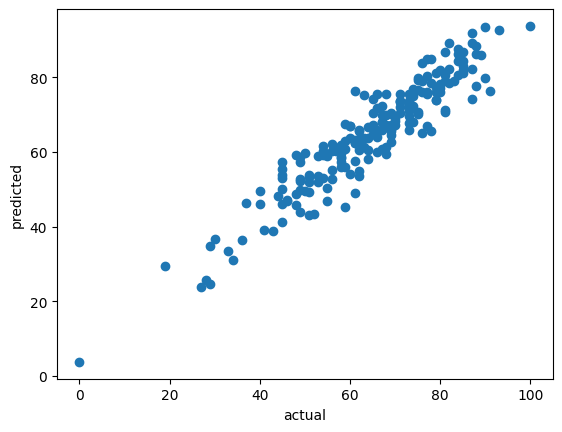

In [14]:
plt.scatter(y_test,y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')

<Axes: xlabel='math score'>

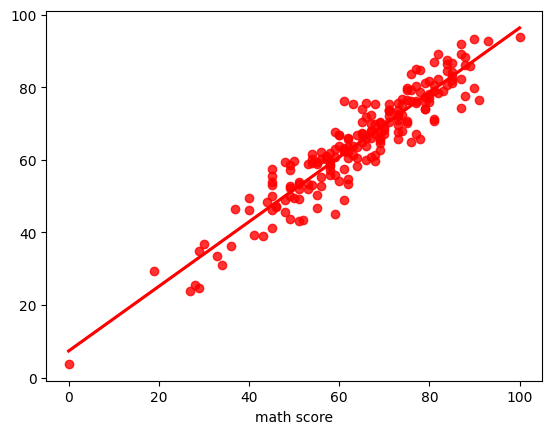

In [15]:
sns.regplot(x=y_test,y=y_pred,ci=None, color='red')

In [16]:
pred_df=pd.DataFrame({'actual value':y_test, 'predicted value':y_pred, 'Difference':y_test-y_pred})
pred_df

,actual value,predicted value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
